<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Neural_Network_Fundamentals_From_Single_Neuron_to_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# =============================================================================
# Neural Network Fundamentals with Synthetic Data
# This example demonstrates the fundamental concepts of artificial neural
# networks using TensorFlow and Keras. It covers the implementation of a
# single neuron, common activation functions (ReLU, Sigmoid, and Tanh),
# synthetic dataset generation, data preprocessing, neural network
# construction, model training, evaluation, visualization of learning
# performance, and prediction for a binary classification task.
# =============================================================================
# ==============================

# =============================================================================
# Part 1: Import Required Libraries
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# =============================================================================
# Part 2: Implementing a Single Artificial Neuron
# =============================================================================

def neuron(inputs, weights, bias, activation='relu'):
    """
    Simulates a single artificial neuron.

    Parameters:
        inputs : Input feature values
        weights : Weight values
        bias : Bias term
        activation : Activation function (relu, sigmoid, tanh)

    Returns:
        Activated neuron output
    """

    z = np.dot(inputs, weights) + bias

    if activation == 'relu':
        return np.maximum(0, z)
    elif activation == 'sigmoid':
        return 1 / (1 + np.exp(-z))
    elif activation == 'tanh':
        return np.tanh(z)
    else:
        return z

# Example inputs
inputs = np.array([0.5, 0.3, 0.8])
weights = np.array([0.4, -0.2, 0.7])
bias = 0.1

print("=== Single Neuron Example ===")
print("ReLU Output:", neuron(inputs, weights, bias, 'relu'))
print("Sigmoid Output:", neuron(inputs, weights, bias, 'sigmoid'))
print("Tanh Output:", neuron(inputs, weights, bias, 'tanh'))

=== Single Neuron Example ===
ReLU Output: 0.7999999999999999
Sigmoid Output: 0.6899744811276125
Tanh Output: 0.6640367702678489


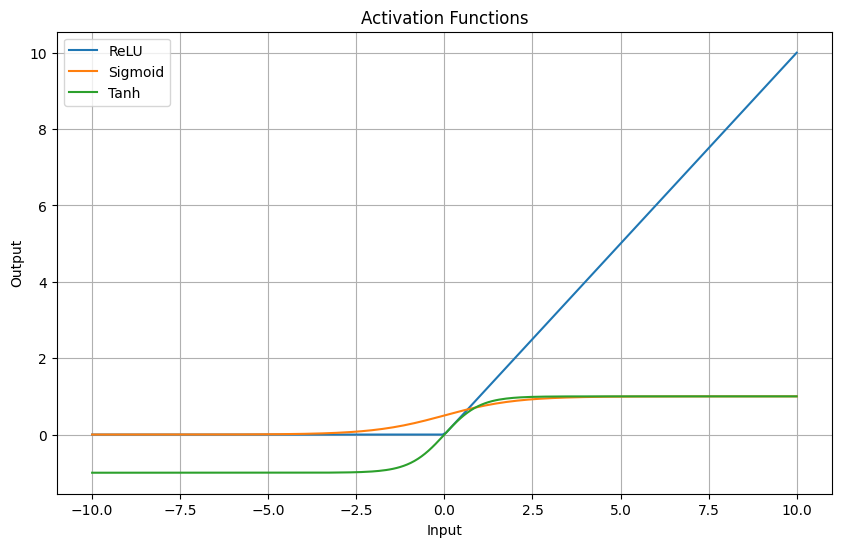

In [ ]:
# =============================================================================
# Part 3: Understanding Activation Functions
# =============================================================================

x = np.linspace(-10, 10, 200)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(10,6))
plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

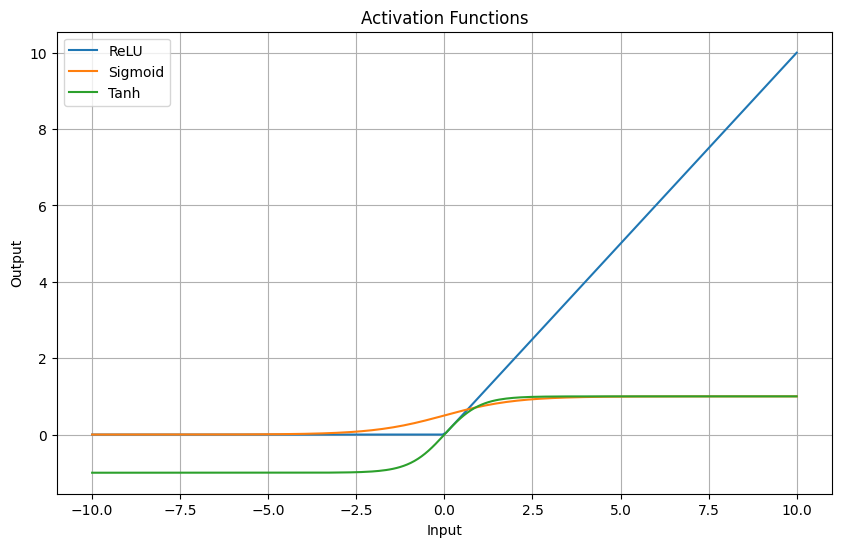

In [ ]:
# =============================================================================
# Part 3: Understanding Activation Functions
# =============================================================================

x = np.linspace(-10, 10, 200)

relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(10,6))
plt.plot(x, relu, label="ReLU")
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# =============================================================================
# Part 4: Generating and Preparing a Synthetic Dataset
# =============================================================================

np.random.seed(42)

# Generate 2,000 samples with 10 features
X = np.random.randn(2000,10)

# Create binary labels
y = (X[:,0] + X[:,1] > 0).astype(float)

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
# =============================================================================
# Part 5: Building and Compiling the Neural Network
# =============================================================================

model = keras.Sequential([

    layers.Input(shape=(10,)),

    layers.Dense(64, activation="relu"),

    layers.Dense(32, activation="relu"),

    layers.Dense(1, activation="sigmoid")

])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nModel Summary")
model.summary()


Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =============================================================================
# Part 6: Training the Neural Network
# =============================================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    verbose=1

)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 0.9825 - val_loss: 0.0436
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0115 - val_accuracy: 0.9825 - val_loss: 0.0440
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0112 - val_accuracy: 0.9825 - val_loss: 0.0470
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9994 - loss: 0.0099 - val_accuracy: 0.9850 - val_loss: 0.0407
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9825 - val_loss: 0.0502
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0088 - val_accuracy: 0.9800 - val_loss: 0.0416
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.9850 - val_loss: 0.0416
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9800 - val_l

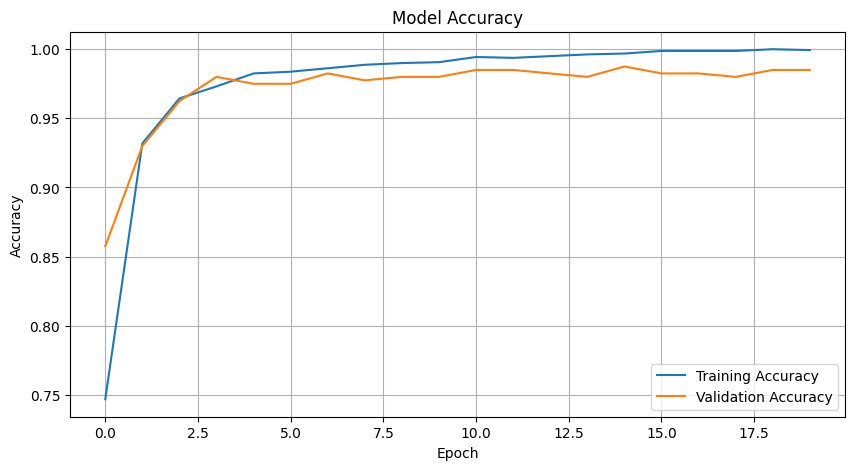

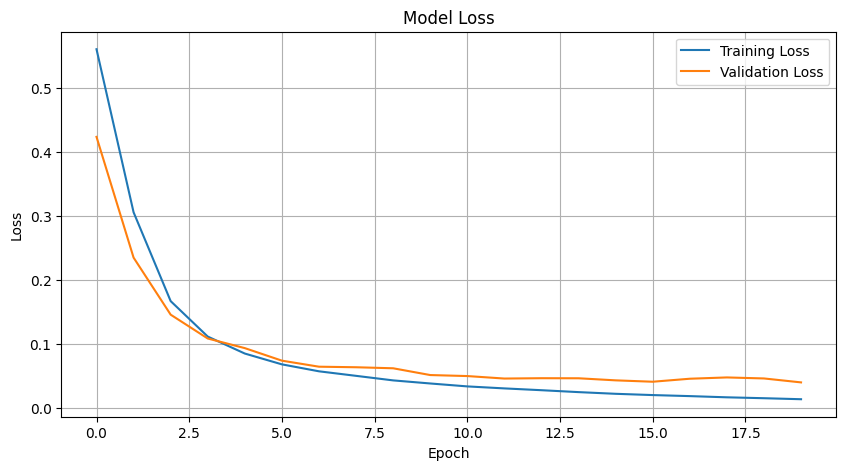

In [ ]:
# =============================================================================
# Part 7: Visualizing Model Performance
# =============================================================================

# Accuracy

plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# Loss

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =============================================================================
# Part 9: Making Predictions
# =============================================================================

predictions = model.predict(X_val[:5])

print("\nPrediction Probabilities")
print(predictions)

print("\nPredicted Classes")

print((predictions > 0.5).astype(int).flatten())

print("\nActual Classes")

print(y_val[:5].astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step

Prediction Probabilities
[[9.5192554e-06]
 [1.0000000e+00]
 [4.7148467e-15]
 [3.8004315e-09]
 [9.9999988e-01]]

Predicted Classes
[0 1 0 0 1]

Actual Classes
[0 1 0 0 1]
